# Vorgehen

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation




# 1. Business Understanding

Grundlagen des Datensatzes:
- 11.430 Internet Seiten
- 50% Phishing, 50% legitime Seiten
- Merkmale
    - 56 Spalten über Struktur und Syntax der URL
    - 24 Spalten über den Inhalt der Internetseite
    - 7 Spalten extrahiert von externen Diensten


Anwendungsfall:
- Erkennung von Phishing anhand von URL und Seiteninhalt, um Nutzer zu warnen
    - Zielvariable: status
    - Beim Empfangen einer URL wird automatisch erkannt, ob die Webseite Phishing-typische Merkmale aufweist
        - Wenn Phishing erkannt wird: Warnung an Nutzer

Ziel:
- Sicherheit für Nutzer erhöhen
- Erkennung in Echtzeit und ohne Blacklist möglich


# 2. Data Understanding

**Collect initial Data:**

Datensatz:
- https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset
- Autor: Shashwat Tiwari

**Describe Data:**

Grundlegende Fakten zum Datensatz

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme(style="whitegrid")

In [24]:
df = pd.read_csv("dataset_phishing.csv")
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [3]:
# Anzahl Spalten, Zeilen
print(df.shape)

(11430, 89)


In [4]:
# Spalten
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  str    
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  11430 non-null

**Explore Data:**

In [5]:
# Zielvariable anschauen
df["status"].value_counts()
# Genau 50/50

status
legitimate    5715
phishing      5715
Name: count, dtype: int64

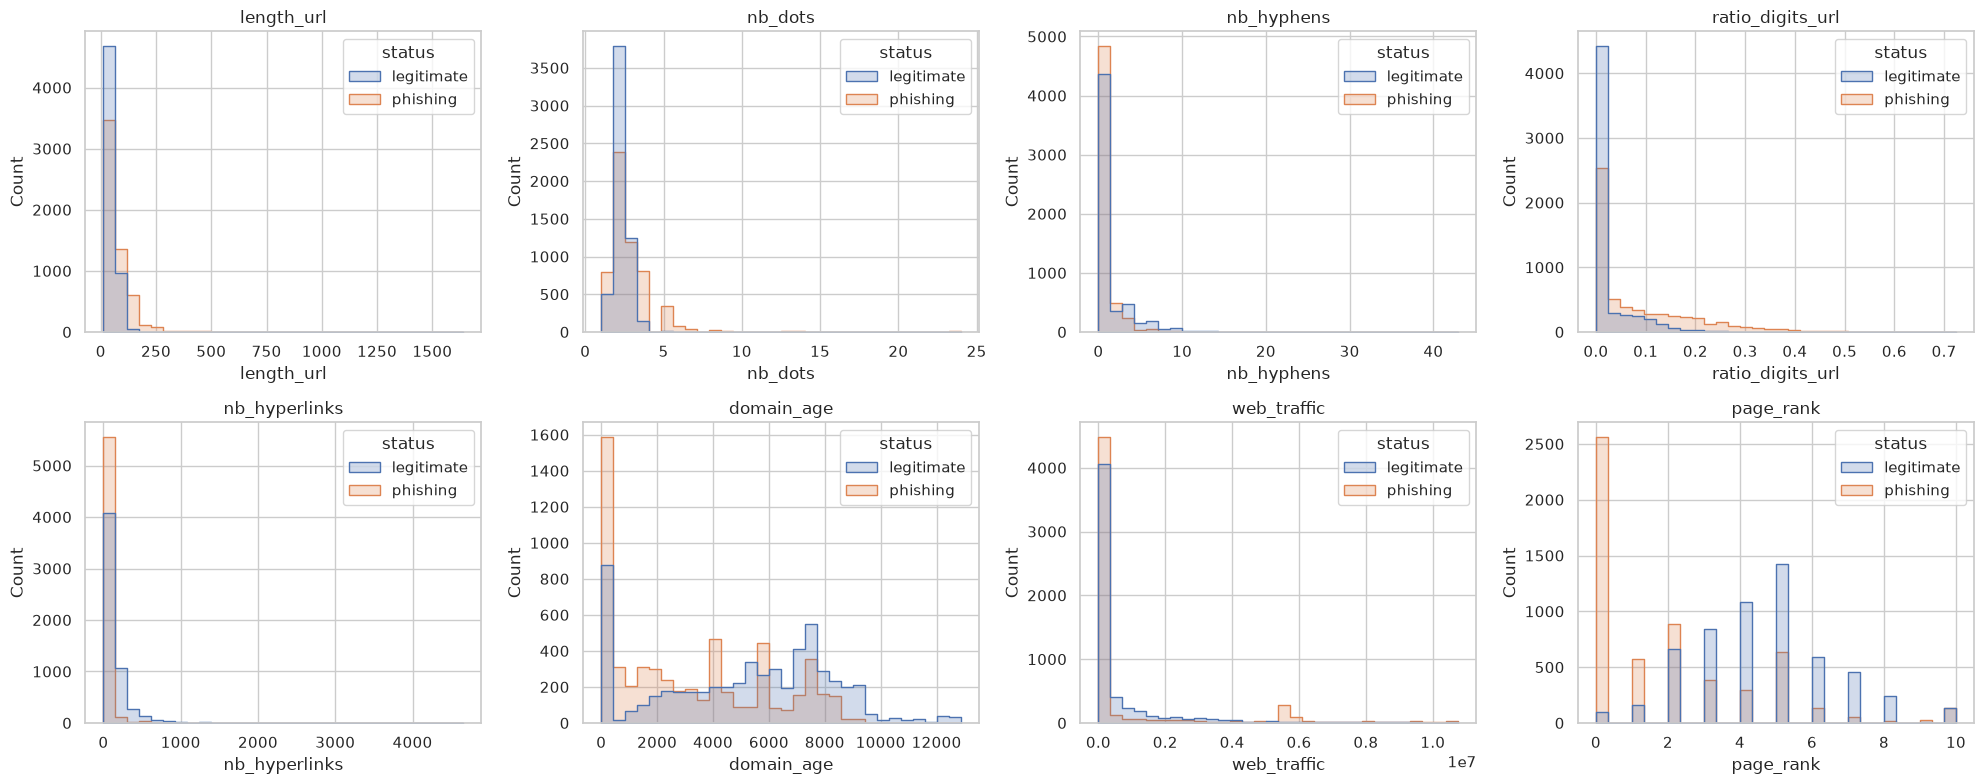

In [7]:
numeric_overview_cols = [
    "length_url", "nb_dots", "nb_hyphens", "ratio_digits_url",
    "nb_hyperlinks", "domain_age", "web_traffic", "page_rank",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.ravel(), numeric_overview_cols):
    sns.histplot(data=df, x=col, hue="status", bins=30, element="step", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

/workspaces/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/workspaces/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


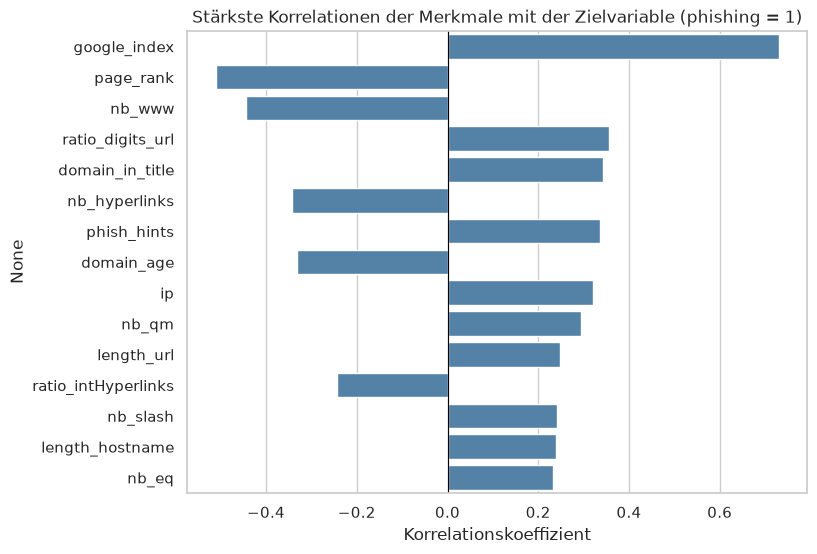

In [8]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

target_numeric = (df["status"] == "phishing").astype(int)
correlations = df[numeric_cols].corrwith(target_numeric).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.head(15).values, y=correlations.head(15).index, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Stärkste Korrelationen der Merkmale mit der Zielvariable (phishing = 1)")
plt.xlabel("Korrelationskoeffizient")
plt.show()

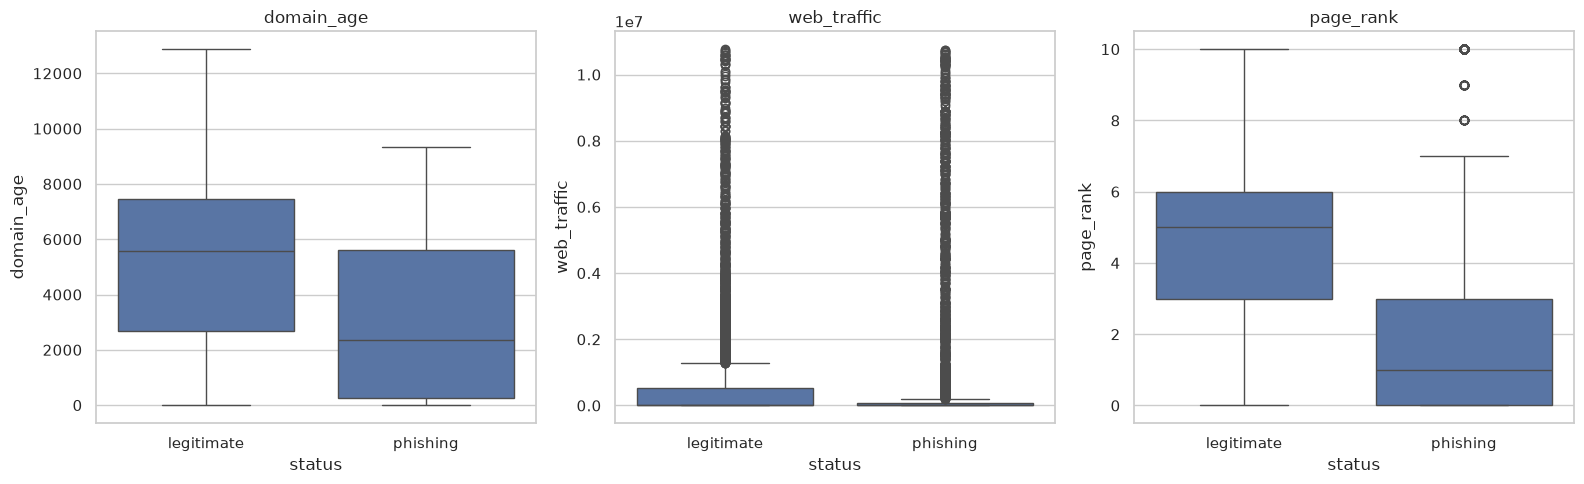

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["domain_age", "web_traffic", "page_rank"]):
    sns.boxplot(data=df, x="status", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Verify Data Quality:**

In [10]:
#fehlende Werte
df.isna().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

In [ ]:
#Duplikate
print("Komplett duplizierte Zeilen:", df.duplicated().sum())
print("Duplizierte URLs:", df["url"].duplicated().sum())

duplicate_urls = df.loc[df["url"].duplicated(keep=False), ["url", "status"]]
duplicate_urls

Komplett duplizierte Zeilen: 0
Duplizierte URLs: 1


,url,status
6035,http://e710z0ear.du.r.appspot.com/c:/users/use...,phishing
11305,http://e710z0ear.du.r.appspot.com/c:/users/use...,phishing


In [ ]:
#Konstante Spalten ohne Informationsgehalt
nunique = df.nunique()
constant_cols = nunique[nunique == 1].index.tolist()
print("Konstante Spalten ohne Informationsgehalt:", constant_cols)

Konstante Spalten ohne Informationsgehalt: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']


In [14]:
#Platzhalter für unbekannte Werte
print("domain_registration_length == -1 (Platzhalter für 'unbekannt'):",
      (df["domain_registration_length"] == -1).sum())
print()
print("domain_age < 0 (Platzhalter für 'unbekannt'):")
print(df.loc[df["domain_age"] < 0, "domain_age"].value_counts())

domain_registration_length == -1 (Platzhalter für 'unbekannt'): 46

domain_age < 0 (Platzhalter für 'unbekannt'):
domain_age
-1     1781
-2       55
-12       1
Name: count, dtype: int64


# 3. Data Preparation

**Select Data:**

In [15]:
constant_cols = df.nunique().loc[lambda s: s == 1].index.tolist()

feature_cols = [c for c in df.columns if c not in constant_cols + ["url", "status"]]
print("Anzahl verbleibender Merkmale:", len(feature_cols))

Anzahl verbleibender Merkmale: 81


**Clean Data:**

In [ ]:
df_clean = df.drop_duplicates(subset="url", keep="first").copy()
print("Zeilen vor Bereinigung:", len(df))
print("Zeilen nach Entfernen der Duplikate:", len(df_clean))

#fehlende Werte durch echtes nan ersetzen
df_clean.loc[df_clean["domain_registration_length"] == -1, "domain_registration_length"] = np.nan
df_clean.loc[df_clean["domain_age"] < 0, "domain_age"] = np.nan

print()
print("Fehlende Werte nach Bereinigung:")
print(df_clean[["domain_registration_length", "domain_age"]].isna().sum())

Zeilen vor Bereinigung: 11430
Zeilen nach Entfernen der Duplikate: 11429

Fehlende Werte nach Bereinigung:
domain_registration_length      46
domain_age                    1837
dtype: int64


**Construct Data:**

In [17]:
df_constructed = df_clean.copy()

df_constructed["domain_registration_length_unknown"] = df_constructed["domain_registration_length"].isna().astype(int)
df_constructed["domain_age_unknown"] = df_constructed["domain_age"].isna().astype(int)

hint_flags = ["phish_hints", "suspecious_tld", "random_domain", "abnormal_subdomain", "punycode"]
df_constructed["hint_score"] = df_constructed[hint_flags].sum(axis=1)

feature_cols = feature_cols + ["domain_registration_length_unknown", "domain_age_unknown", "hint_score"]
print("Anzahl Merkmale nach Construct Data:", len(feature_cols))
df_constructed[["domain_registration_length_unknown", "domain_age_unknown", "hint_score"]].describe()

Anzahl Merkmale nach Construct Data: 84


,domain_registration_length_unknown,domain_age_unknown,hint_score
count,11429.000000,11429.000000,11429.000000
mean,0.004025,0.160731,0.450958
std,0.063317,0.367299,0.910972
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000
max,1.000000,1.000000,10.000000


**Integrate Data:**

(entfällt weil keine 2 Datenquellen existieren)

**Format Data:**

In [28]:
#Zielvariable anpassen an Boolean (phishing = 1, legitimate = 0)
df_constructed["status"] = (df_constructed["status"] == "phishing").astype(int)

In [30]:
#In Trainings- und Testdaten aufteilen
from sklearn.model_selection import train_test_split

label = df_constructed["status"]
features = df_constructed[feature_cols]

train_data, test_data, train_label, test_label = train_test_split(
    features, label, test_size=0.2, stratify=label, random_state=0
)

print("Training:", train_data.shape, "Test:", test_data.shape)
print("Klassenanteil Training:", train_label.mean().round(3), "| Test:", test_label.mean().round(3))

Training: (9143, 84) Test: (2286, 84)
Klassenanteil Training: 0.5 | Test: 0.5


In [31]:
#Imputation und Skalierung
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preparation_pipeline = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), feature_cols),
])

train_prepared = preparation_pipeline.fit_transform(train_data)
test_prepared = preparation_pipeline.transform(test_data)

print("Form der aufbereiteten Trainingsdaten:", train_prepared.shape)
print("Form der aufbereiteten Testdaten:", test_prepared.shape)

Form der aufbereiteten Trainingsdaten: (9143, 84)
Form der aufbereiteten Testdaten: (2286, 84)


## 4 - Modelling

## 3 - Evalutation

## 4 - Deployment